In [2]:
import os
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import torch.nn as nn
import torch.optim as optim

train_data = MNIST(root='./data', train=True, transform=transforms.ToTensor(), download=os.path.exists("./data"))
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

In [4]:
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 10),
        )

    def forward(self, x):
        return self.net(x)

model = MNISTModel()
print(model)


MNISTModel(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=16, bias=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=10, bias=True)
  )
)
MNISTModel(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=16, bias=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=10, bias=True)
  )
)


Loss: 533.96
Loss: 259.28
Loss: 221.37
Loss: 197.26
Loss: 181.57
Loss: 169.20
Loss: 159.94
Loss: 151.57
Loss: 144.07
Loss: 138.88
Loss: 134.36
Loss: 129.18
Loss: 124.59
Loss: 121.60
Loss: 118.19
Loss: 115.26
Loss: 112.56
Loss: 109.95
Loss: 107.53
Loss: 104.87
Loss: 102.86
Loss: 101.87
Loss: 99.40
Loss: 98.04
Loss: 95.94
Loss: 93.59
Loss: 91.97
Loss: 90.54
Loss: 90.23
Loss: 88.09
Loss: 86.48
Loss: 85.71
Loss: 83.28
Loss: 82.75
Loss: 82.63
Loss: 80.76
Loss: 80.40
Loss: 78.98
Loss: 76.74
Loss: 77.19
Loss: 75.26
Loss: 74.50
Loss: 74.15
Loss: 72.58
Loss: 72.05
Loss: 70.83
Loss: 70.00
Loss: 68.89
Loss: 68.43
Loss: 69.20


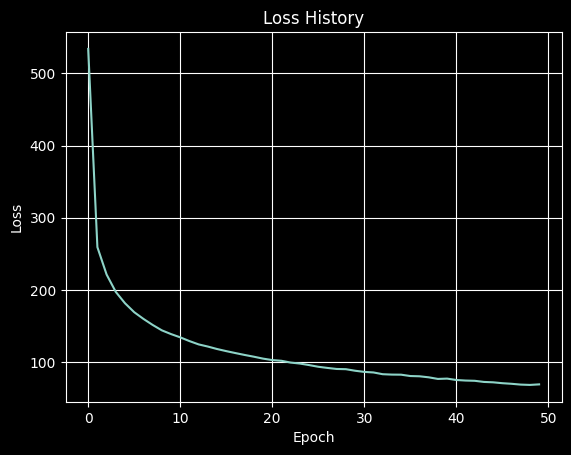

Loss: 67.89
Loss: 66.32
Loss: 66.05
Loss: 66.63
Loss: 64.47
Loss: 63.85
Loss: 64.72
Loss: 63.75
Loss: 62.61
Loss: 61.72
Loss: 61.64
Loss: 60.88
Loss: 60.90
Loss: 59.66
Loss: 59.41
Loss: 58.36
Loss: 58.33
Loss: 57.46
Loss: 57.56
Loss: 56.30
Loss: 56.38
Loss: 56.03
Loss: 55.18


In [5]:


from matplotlib import pyplot as plt

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_history = []

for epoch in range (50):
    total_loss = 0
    for images, labels in train_loader:
        pre_d = model(images)
        loss = loss_fn(pre_d, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_history.append(total_loss)
    print(f"Loss: {total_loss:.2f}")

plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss History")
plt.grid(True)
plt.show()

